**Mahan Madani - 830504035**

Assignment 2 | Question 2: Image Compression with Autoencoder

## Table of Contents

- [Import libraries and Custom Classes](#import-libraries-and-custom-classes)
- [Load and Prepare Dataset](#load-and-prepare-dataset)
    - [Sample image](#sample-image)
- [Image to Vector Transformation](#image-to-vector-transformation)
- [Helper Functions](#helper-functions)
- [2.1 Hidden Layer Nuerons](#21-hidden-layer-neurons)
    - [4 Neurons](#4-neurons)
    - [16 Neurons](#16-neurons)
    - [32 Neurons](#32-neurons)
    - [Hidden Layer Comparison](#hidden-layer-comparison)
- [2.2 Block Size](#22-block-size)
    - [4*4 Blocks](#4--4-blocks)
    - [8*8 Blocks](#8--8-blocks)
    - [16*16 Blocks](#16--16-blocks)
    - [Block Size Comparison](#block-size-comparison)
- [2.3 Momentum](#23-momentum)
    - [Momentum 0.0](#momentum-00)
    - [Momentum 0.5](#momentum-05)
    - [Momentum Comparison](#momentum-comparison)

## Import Libraries and Custom Classes

In [6]:
import numpy as np
import struct
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
import os
import math

In [7]:
from MLP import MLP, LinearLayer
from MLP import MSELoss, CrossEntropyLoss, WeightInitializer
from MLP import ReLU, LeakyReLU, Linear, Sigmoid, Tanh, Softmax
from MLP import shuffle_data, reset_seed, plot_metric_over_epoch, calculate_psnr, GLOBAL_SEED
from MLP import plot_train_metrics

## Load and Prepare Dataset

Download the Fashion_MNIST dataset and extract the .gz files in the selected path.

In [42]:
IMAGE_DIM = 28
fashion_mnist_path = "Dataset/Fashion_MNIST"

In [43]:
# Retrieve Fashion MNIST Images and labels
def load_idx_images(filename):
    with open(filename, "rb") as f:
        magic, num, rows, cols = struct.unpack(">IIII", f.read(16))
        data = np.frombuffer(f.read(), dtype=np.uint8)
        data = data.reshape(num, rows, cols)
    return normalize_pixels(data)

def load_idx_labels(filename):
    with open(filename, "rb") as f:
        magic, num = struct.unpack(">II", f.read(8))
        labels = np.frombuffer(f.read(), dtype=np.uint8)
    return labels


# Normalize and denormalize pixel values
def normalize_pixels(image):
    return image / 255.0

def denormalize_pixels(image):
    return (image * 255).astype(np.uint8)

In [44]:
train_images = load_idx_images(f"{fashion_mnist_path}/train-images-idx3-ubyte")
train_labels = load_idx_labels(f"{fashion_mnist_path}/train-labels-idx1-ubyte")

test_images = load_idx_images(f"{fashion_mnist_path}/t10k-images-idx3-ubyte")
test_labels = load_idx_labels(f"{fashion_mnist_path}/t10k-labels-idx1-ubyte")

In [45]:
# Display a numpy array as an image
def display_image(image, title=''):
    if image.shape is not (IMAGE_DIM, IMAGE_DIM):
        image = image.reshape(IMAGE_DIM, IMAGE_DIM)
    plt.imshow(image, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()
    
def display_and_compare_images(img_original, img_reconstructed):
    plt.figure(figsize=(7, 4))
    
    plt.subplot(1, 2, 1)
    plt.axis('off')
    plt.imshow(img_original, cmap='gray')
    plt.title('Original Image')
    
    plt.subplot(1, 2, 2)
    plt.axis('off')
    plt.imshow(img_reconstructed, cmap='gray')
    plt.title('Reconstructed Image')
    
    plt.tight_layout()
    plt.show()

### One-hot encoding the labels

In [46]:
FASHION_MNIST_LABELS = {
    0: "T-shirt/top",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle boot"
}

In [47]:
def one_hot_encode(labels, num_classes=10):
    # encoder = OneHotEncoder(sparse_output=False)
    # return encoder.fit_transform(labels.reshape(-1, 1))

    one_hot = np.zeros((labels.size, num_classes), dtype=np.float32)
    one_hot[np.arange(labels.size), labels] = 1.0
    return one_hot


def one_hot_to_label(one_hot_vec, label_dict=FASHION_MNIST_LABELS):
    index = int(np.argmax(one_hot_vec))
    return label_dict[index]

In [48]:
X_train = train_images.reshape(len(train_images), -1)
X_test = test_images.reshape(len(test_images), -1)

y_train = one_hot_encode(train_labels)
y_test = one_hot_encode(test_labels)

In [49]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(60000, 784)
(60000, 10)
(10000, 784)
(10000, 10)


### Sample image:

Sneaker


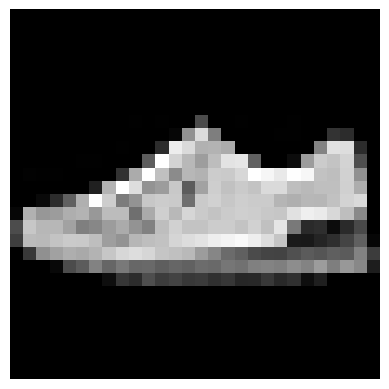

In [50]:
img = X_train[126]
print(one_hot_to_label(y_train[126]))
display_image(img)

## Create Train-Validation Set

In [51]:
def train_val_split(X, y, val_ratio, shuffle=True, seed=GLOBAL_SEED):
    N = len(X)
    indices = np.arange(N)

    np.random.seed(seed)
    if shuffle:
        np.random.shuffle(indices)

    val_size = int(N * val_ratio)

    val_idx = indices[:val_size]
    train_idx = indices[val_size:]

    return X[train_idx], y[train_idx], X[val_idx], y[val_idx]


In [52]:
VAL_RATIO = 0.2
X_train, y_train, X_val, y_val = train_val_split(X_train, y_train, VAL_RATIO)

In [53]:
print(X_train.shape)
print(X_val.shape)

(48000, 784)
(12000, 784)


In [54]:
INPUT_SIZE = X_train.shape[1]
VALIDATION_IDX = 666  # used to display one image from the validation set and its reconstruction

## Helper Functions

In [55]:
def test_with_PSNR(reconstructed_images, target_images, val_idx):    
    psnr_sum = 0
    for target_image, reconstructed_image in zip(target_images, reconstructed_images):
        psnr_sum += calculate_psnr(target_image, reconstructed_image)
    psnr_mean = psnr_sum / len(target_images)
    print(f"Mean PSNR: {psnr_mean:8f}\n")
    
    # Display and compare one image and its respective reconstruction
    target_image = target_images[val_idx]
    reconstructed_image = reconstructed_images[val_idx]

    print(f"Sample image", end=' - ')
    print(f"PSNR: {calculate_psnr(target_image, reconstructed_image):6f}" )
    display_and_compare_images(img_original=target_image, img_reconstructed=reconstructed_image)
    
    return float(psnr_mean)

In [56]:
def get_model_predictions(model, vectorized_images):
    predictions = []
    for vector in vectorized_images:
        predictions.append(model.forward(vector))
    return np.array(predictions)

In [57]:
def train_autoencoder_model(model, X_train, X_val, epochs=50, batch_size=1):    
    # Train Autoencoder Model
    model.train(X_train, X_train, batch_size=batch_size,
                epochs=epochs, print_interval=math.ceil(epochs/10), 
                test_model=True, X_test=X_val, Y_test=X_val)

In [58]:
def evaluate_autoencoder_model(model, X_val):
    # Plot model's loss history
    print("Loss history over epochs:")
    plot_metric_over_epoch(model.train_loss_list, model.test_loss_list, val=True, title="Mean Loss over Epochs", figure_size=(6,4))
    
    # Reconstruct validation images from model prediction 
    val_predictions = get_model_predictions(model, X_val)
    val_predictions = val_predictions.reshape(-1, IMAGE_DIM, IMAGE_DIM)
    X_val = X_val.reshape(-1, IMAGE_DIM, IMAGE_DIM)
    
    # Evaluate image reconstructione by comparing them to the original image using the PSNR metric
    print("\nValidation data", end=' - ')
    val_psnr = test_with_PSNR(reconstructed_images=val_predictions, target_images=X_val, val_idx=VALIDATION_IDX)
    
    return val_psnr

In [59]:
# def plot_metric_over_epoch(train_metric_list, test_metric_list=None, val=False, title="", y_label="Mean Loss", figure_size=(8, 5)):
#     plt.figure(figsize=figure_size)

#     epochs = np.arange(1, len(train_metric_list) + 1)
#     plt.plot(epochs, train_metric_list, label='Train', linewidth=2)
#     if test_metric_list is not None:
#         label = 'Validation' if val else 'Test' 
#         plt.plot(epochs, test_metric_list, color='salmon', label=label, linewidth=2)

#     plt.xlabel('Epoch')
#     plt.ylabel(y_label)
#     plt.title(title)
#     plt.grid(True, linestyle="--", alpha=0.4)
#     plt.legend()
#     # plt.tight_layout()
#     plt.show()

## 3.1 Train Autoencoder

### 3.1.a Hidden Layer Neurons

In [61]:
lr = 0.001
epochs = 10
batch_size = 1

Model 1: Hidden layer size = 64

In [ ]:
hidden_layer_size = 64

model_1 = MLP(
    layer_sizes=[INPUT_SIZE, hidden_layer_size, INPUT_SIZE],
    activations=[Sigmoid(), Sigmoid()],
    loss="mse",
    lr=lr,
    weight_type="xavier"
)

print(model_1)

In [ ]:
train_autoencoder_model(model_1, X_train, X_val, epochs, batch_size)

In [ ]:
psnr_1 = evaluate_autoencoder_model(model_1, X_val)

Model 2: Hidden layer size = 128

In [ ]:
hidden_layer_size = 128

model_2 = MLP(
    layer_sizes=[INPUT_SIZE, hidden_layer_size, INPUT_SIZE],
    activations=[Sigmoid(), Sigmoid()],
    loss="mse",
    lr=lr,
    weight_type="xavier"
)

print(model_2)

In [ ]:
train_autoencoder_model(model_2, X_train, X_val, epochs, batch_size)

In [ ]:
psnr_2 = evaluate_autoencoder_model(model_2, X_val)

### 3.1.b Model Architecture

Model 3: Architecture  768 - 256 - 64 - 256 - 768

In [ ]:
model_3 = MLP(
    layer_sizes=[INPUT_SIZE, 256, 64, 256, INPUT_SIZE],
    activations=[Sigmoid(), Sigmoid(), Sigmoid(), Sigmoid()],
    loss="mse",
    lr=lr,
    weight_type="xavier"
)

print(model_3)

In [ ]:
train_autoencoder_model(model_3, X_train, X_val, epochs, batch_size)

In [ ]:
psnr_3 = evaluate_autoencoder_model(model_3, X_val)

Model 4: Architecture  768 - 256 - 128 - 64 - 128 - 256 - 768

In [ ]:
model_4 = MLP(
    layer_sizes=[INPUT_SIZE, 256, 128, 64, 128, 256, INPUT_SIZE],
    activations=[Sigmoid(), Sigmoid(), Sigmoid(), Sigmoid(), Sigmoid(), Sigmoid()],
    loss="mse",
    lr=lr,
    weight_type="xavier"
)

print(model_4)

In [ ]:
train_autoencoder_model(model_4, X_train, X_val, epochs, batch_size)

In [ ]:
psnr_4 = evaluate_autoencoder_model(model_4, X_val)

Best Architecture: 

In [ ]:
best_layer_sizes = [INPUT_SIZE, 256, 64, 256, INPUT_SIZE]

### 3.1c ReLU

In [ ]:
model_5 = MLP(
    layer_sizes=best_layer_sizes,
    activations=[ReLU() for _ in range(len(best_layer_sizes)-1)],
    loss="mse",
    lr=lr,
    weight_type="xavier"
)

print(model_5)

In [ ]:
train_autoencoder_model(model_5, X_train, X_val, epochs, batch_size)

In [ ]:
psnr_5 = evaluate_autoencoder_model(model_5, X_val)

ReLU perform better than signoid:

In [ ]:
best_activations = [ReLU() for _ in range(len(best_layer_sizes)-1)]

### 3.1.d Learning Rate

Learning rate = 0.01

In [ ]:
lr = 0.01

model_6 = MLP(
    layer_sizes=best_layer_sizes,
    activations=best_activations,
    loss="mse",
    lr=lr,
    weight_type="xavier"
)

print(model_6)

In [ ]:
train_autoencoder_model(model_6, X_train, X_val, epochs, batch_size)

In [ ]:
psnr_6 = evaluate_autoencoder_model(model_6, X_val)

Learning Rate = 0.000001

In [ ]:
lr = 0.000001

model_7 = MLP(
    layer_sizes=best_layer_sizes,
    activations=best_activations,
    loss="mse",
    lr=lr,
    weight_type="xavier"
)

print(model_7)

In [ ]:
train_autoencoder_model(model_7, X_train, X_val, epochs, batch_size)

In [ ]:
psnr_7 = evaluate_autoencoder_model(model_7, X_val)

Best Learning Rate:

In [ ]:
lr = 0.001

### 3.1e Batch Gradient Descent

Batch Size = 8

In [ ]:
batch_size = 8

model_8 = MLP(
    layer_sizes=best_layer_sizes,
    activations=best_activations,
    loss="mse",
    lr=lr,
    weight_type="xavier"
)

print(model_8)

In [ ]:
train_autoencoder_model(model_8, X_train, X_val, epochs, batch_size)

In [ ]:
psnr_8 = evaluate_autoencoder_model(model_8, X_val)

Batch Size = 16

In [ ]:
batch_size = 16

model_9 = MLP(
    layer_sizes=best_layer_sizes,
    activations=best_activations,
    loss="mse",
    lr=lr,
    weight_type="xavier"
)

print(model_9)

In [ ]:
train_autoencoder_model(model_9, X_train, X_val, epochs, batch_size)

In [ ]:
psnr_9 = evaluate_autoencoder_model(model_9, X_val)

### Images with the Highest and Lowest Loss

## 3.2 Train Classifier

In [106]:
def train_classifier_model(model, X_train, y_train, X_val, y_val, epochs=50, batch_size=1):    
    t = True
    if X_val is None or y_val is None:
        t = False
    model.train(X_train, y_train, batch_size=batch_size,
                epochs=epochs, print_interval=math.ceil(epochs/10), 
                test_model=t, X_test=X_val, Y_test=y_val)

In [107]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

def evaluate_classifier_model(model, X_val, y_val):
    # # Plot model's loss history
    # print("Loss history over epochs:")
    # plot_metric_over_epoch(model.train_loss_list, model.test_loss_list, val=True, title="Mean Loss over Epochs", figure_size=(6,4))
    
    # Make predictions about the validation data
    val_predictions = get_model_predictions(model, X_val)

    import numpy as np

    true_labels = np.argmax(y_val, axis=1)
    pred_labels = np.argmax(val_predictions, axis=1)
    

    acc  = accuracy_score(true_labels, pred_labels)
    prec = precision_score(true_labels, pred_labels, average='macro')
    rec  = recall_score(true_labels, pred_labels, average='macro')
    f1   = f1_score(true_labels, pred_labels, average='macro')
    cm   = confusion_matrix(true_labels, pred_labels)

    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1-score:", f1)
    # print("Confusion Matrix:\n", cm)
    
    
    # Plot confusion matrix
    plt.figure(figsize=(6, 5))
    plt.imshow(cm, interpolation='nearest', cmap="viridis")
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

    # Add numbers inside cells
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.tight_layout()
    plt.show()

In [108]:
model_x = MLP(
    layer_sizes=[INPUT_SIZE, 128, 64, 32, 10],
    activations=[ReLU(), ReLU(), ReLU(), Softmax()],
    loss="cross_entropy",
    lr=lr,
    weight_type="xavier"
)

print(model_x)

Multi-Layer Perceptron Details:
Input Size: 784
Output Size: 10
Architecture:
  Layer  1: Linear Block (784, 128),   Activation: ReLU
  Layer  2: Linear Block (128, 64),   Activation: ReLU
  Layer  3: Linear Block (64, 32),   Activation: ReLU
  Layer  4: Linear Block (32, 10),   Activation: Softmax
Learning Rate: 0.001
Momentum: 0.0
Weight Initialization Type: xavier


In [109]:
train_classifier_model(model_x, X_train, y_train, X_val, y_val, epochs=10, batch_size=16)

(48000, 10)


Training:   0%|          | 0/10 [00:00<?, ?Epoch/s]

Epoch    1 /   10,   Train Loss: 0.944357,   Test Loss: 0.941440
Epoch    2 /   10,   Train Loss: 0.696375,   Test Loss: 0.692313
Epoch    3 /   10,   Train Loss: 0.608963,   Test Loss: 0.605840
Epoch    4 /   10,   Train Loss: 0.562368,   Test Loss: 0.560626
Epoch    5 /   10,   Train Loss: 0.532585,   Test Loss: 0.532381
Epoch    6 /   10,   Train Loss: 0.512072,   Test Loss: 0.513676
Epoch    7 /   10,   Train Loss: 0.495380,   Test Loss: 0.498766
Epoch    8 /   10,   Train Loss: 0.482183,   Test Loss: 0.487388
Epoch    9 /   10,   Train Loss: 0.471399,   Test Loss: 0.478512
Epoch   10 /   10,   Train Loss: 0.462017,   Test Loss: 0.471024

Total training time: 3 min 50.957316 sec


In [111]:
model_x.loss_fn.loss(get_model_predictions(model_x, X_test), y_test)

np.float64(0.5037920241663707)

In [112]:
model_x.loss_fn.loss(get_model_predictions(model_x, X_val), y_val)

np.float64(0.47102427705786415)

In [113]:
model_x.loss_fn.loss(get_model_predictions(model_x, X_train), y_train)

np.float64(0.46201706469932363)

Accuracy: 0.8343125
Precision: 0.8457778304100305
Recall: 0.8344311508437269
F1-score: 0.837347812004151


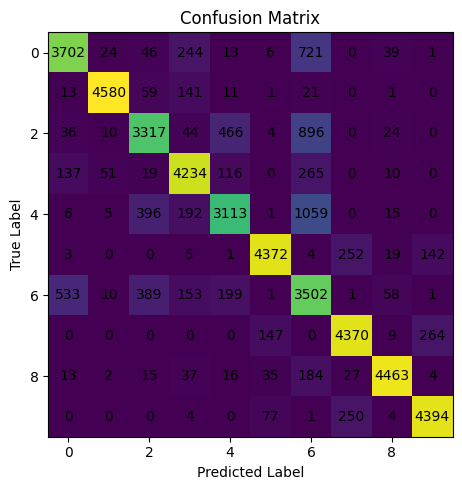

In [116]:
evaluate_classifier_model(model_x, X_train, y_train)

Accuracy: 0.83475
Precision: 0.8470675037296367
Recall: 0.834399773503271
F1-score: 0.8369429476486904


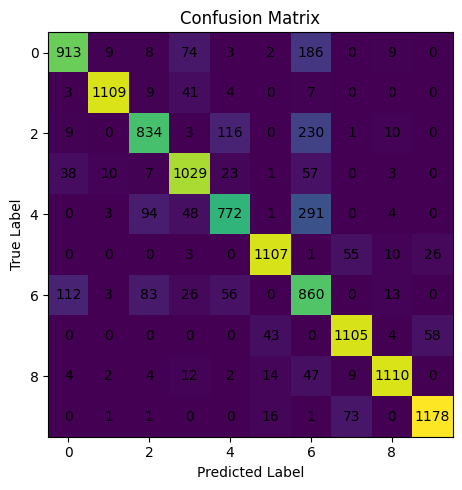

In [114]:
evaluate_classifier_model(model_x, X_val, y_val)

Accuracy: 0.8177
Precision: 0.8331888826941889
Recall: 0.8177
F1-score: 0.8217372348404355


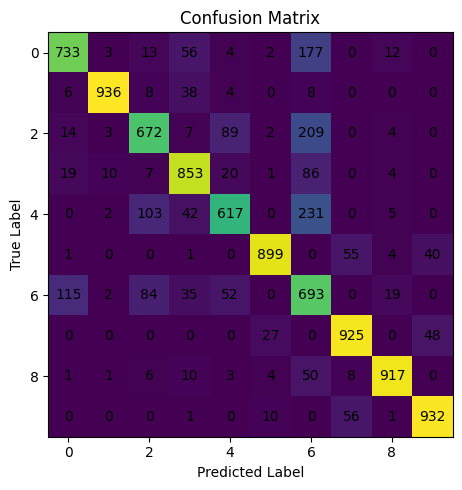

In [115]:
evaluate_classifier_model(model_x, X_test, y_test)

In [ ]:
print( 'Model Evaluation Summary:\n\n' +
       '         Model        | Train Loss | Test Loss  | Train PSNR  |  Test PSNR  |  Convergence Time\n' +
       '-------------------------------------------------------------------------------------------------\n' +
      f'    Momentum = 0.0    |  {m0_model.train_loss_list[-1]:6f}  |  {m0_model.test_loss_list[-1]:6f}  |  {m0_psnr_train:6f}  |  {m0_psnr_test:6f}  |     10 Epochs\n' +
      f'    Momentum = 0.5    |  {m05_model.train_loss_list[-1]:6f}  |  {m05_model.test_loss_list[-1]:6f}  |  {m05_psnr_train:6f}  |  {m05_psnr_test:6f}  |     15 Epochs\n')

In [ ]:
plot_train_metrics([n4_model.test_loss_list, n8_model.test_loss_list, n16_model.test_loss_list],
                    labels=['Block size 4*4', 'Block size 8*8', 'Block size 16*16'],
                    title="Mean Loss on test data",
                    figure_size=(6, 4))